In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

import matplotlib.pyplot as plt
import seaborn as sns #Graph 

/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/netflix-shows")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/shivamb/netflix-shows


In [3]:
file_path = os.path.join(path, 'netflix_titles.csv')
df = pd.read_csv(file_path)
df = df.replace([np.nan, None, '', ' '], 'Unknown')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [4]:
# 1. XỬ LÝ DỮ LIỆU RỖNG (MISSING VALUES)
# Điền "Unknown" cho các cột thiếu nhiều dữ liệu như director (30%) và cast (9%)
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Xóa các dòng bị thiếu ở những cột quan trọng nhưng tỷ lệ lỗi cực nhỏ
df = df.dropna(subset=['date_added', 'rating'])

# 2. CHUẨN HÓA THỜI GIAN (DATETIME PARSING)
# Xóa khoảng trắng thừa và chuyển về định dạng datetime
# 1. Xóa khoảng trắng thừa
df['date_added'] = df['date_added'].str.strip()

# 2. Ép kiểu thời gian với "errors='coerce'" để bỏ qua các chữ "Unknown"
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# 3. Trích xuất Năm và Tháng (Các dòng NaT sẽ tự động trả về NaN)
df['added_year'] = df['date_added'].dt.year
df['added_month'] = df['date_added'].dt.month

# 4. Kiểm tra xem có bao nhiêu bộ phim đang bị khuyết ngày tháng
print("Số lượng phim bị thiếu ngày tháng (NaT):", df['date_added'].isna().sum())

# 3. TÁCH BIẾN SỐ THỜI LƯỢNG (DURATION)
# Tách cột 'duration' thành con số (value) và đơn vị (unit)
df[['duration_val', 'duration_unit']] = df['duration'].str.split(' ', expand=True)

# Chuyển đổi con số sang dạng numeric, bỏ qua các giá trị văn bản ngoại lệ
df['duration_val'] = pd.to_numeric(df['duration_val'], errors='coerce')

# Nghiệm thu kết quả cuối cùng
print("Kích thước bộ dữ liệu sau khi làm sạch:", df.shape)
display(df.head())

Số lượng phim bị thiếu ngày tháng (NaT): 10
Kích thước bộ dữ liệu sau khi làm sạch: (8807, 16)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year,added_month,duration_val,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,90.0,min
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,2.0,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,1.0,Season
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,1.0,Season
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0,2.0,Seasons


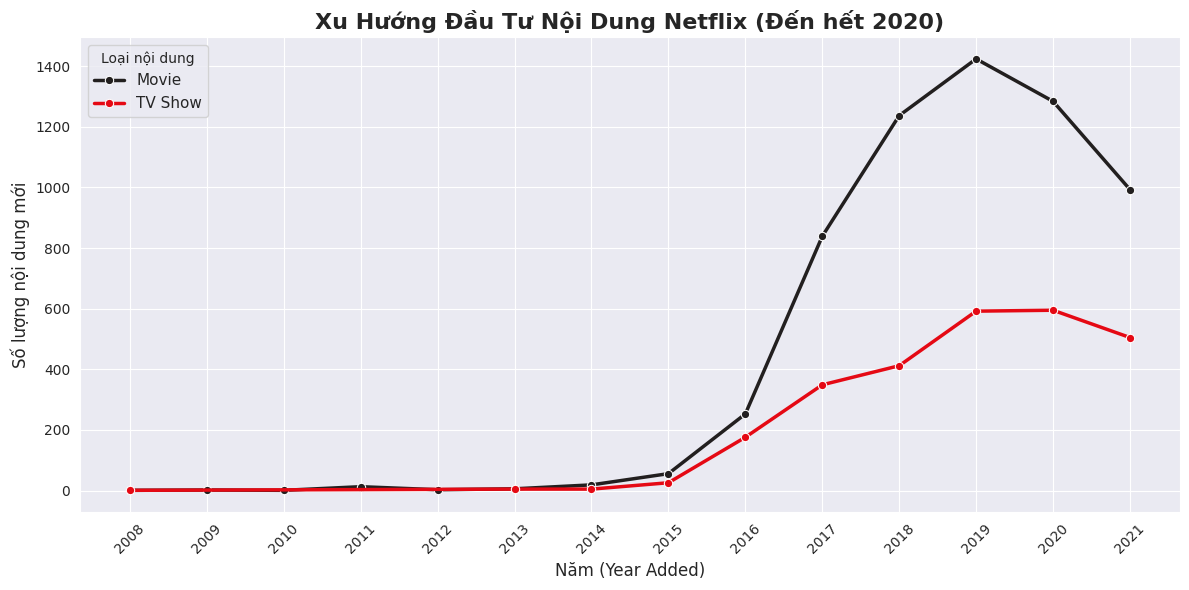

In [5]:
# 1. Chuẩn bị dữ liệu
# Nhóm dữ liệu theo năm và loại hình (type) rồi đếm số lượng
trend_data = df.groupby(['added_year', 'type']).size().reset_index(name='count')

# Lọc bỏ năm 2021 (nếu dữ liệu chưa cập nhật trọn vẹn cả năm để tránh biểu đồ bị gãy dốc đứng)
# (Dựa trên metadata, dataset cập nhật đến cuối tháng 9/2021)
trend_data = trend_data[trend_data['added_year'] < 2022]

# 2. Cài đặt trực quan (Phong cách Netflix)
plt.figure(figsize=(12, 6))
sns.set_style("darkgrid")

# Vẽ biểu đồ đường (Line Chart)
# Sử dụng mã màu đỏ đặc trưng của Netflix (#E50914) và màu xám đậm (#221f1f)
sns.lineplot(data=trend_data, x='added_year', y='count', hue='type', 
             palette=['#221f1f', '#E50914'], linewidth=2.5, marker='o')

# 3. Trang trí biểu đồ
plt.title('Xu Hướng Đầu Tư Nội Dung Netflix (Đến hết 2020)', fontsize=16, fontweight='bold')
plt.xlabel('Năm (Year Added)', fontsize=12)
plt.ylabel('Số lượng nội dung mới', fontsize=12)
plt.xticks(trend_data['added_year'].unique(), rotation=45)
plt.legend(title='Loại nội dung', fontsize=11)
plt.tight_layout()

# Hiển thị
plt.show()

Một sự tăng trưởng bùng nổ từ khoảng năm 2015-2016. Đây chính là lúc Netflix chính thức chuyển mình từ một công ty cho thuê đĩa DVD sang đế chế Streaming toàn cầu.

Dù Movie luôn có số lượng cao hơn, nhưng hãy chú ý đến độ dốc của đường màu đỏ (TV Show). Tốc độ tăng trưởng của TV Show trong những năm gần đây cực kỳ ấn tượng, minh chứng cho việc tụi mình đang dồn tiền mua bản quyền và sản xuất phim nhiều tập để "trói chân" khán giả vào các gói cước gia hạn hàng tháng.
Covid 19
1. Sự "đứt gãy" của chuỗi sản xuất toàn cầuNhu cầu tăng nhưng nguồn cung đứt: Khi đại dịch bùng phát mạnh vào đầu năm 2020, các đợt phong tỏa đã biến phòng khách thành rạp chiếu phim, giúp lượng người dùng đăng ký mới của tụi mình tăng kỷ lục. Nhưng nghịch lý ở chỗ: mọi phim trường từ Hollywood đến Bollywood đều phải đóng cửa.Độ trễ của ngành công nghiệp điện ảnh: Một bộ phim hay series bạn xem hôm nay thường đã phải mất 1-2 năm để bấm máy và hậu kỳ. Việc ngừng quay phim hàng loạt trong năm 2020 đã tạo ra một khoảng trống nội dung khổng lồ, dẫn đến việc thiếu hụt trầm trọng phim mới để phát hành trên nền tảng trong giai đoạn cuối 2020 và 2021.2. Góc nhìn thực tế từ Dữ liệu (Data Reality)Yếu tố "thời hạn" của Dataset: Là một người làm dữ liệu, chúng ta phải luôn soi kỹ "hạn sử dụng" của nguồn thông tin. Nếu bạn nhìn vào mô tả của bộ dataset trên Kaggle, dữ liệu này thực chất chỉ ghi nhận các bộ phim được thêm vào nền tảng đến ngày 24 tháng 9 năm 2021.  Việc năm 2021 bị thiếu mất 3 tháng cuối (vốn luôn là mùa cao điểm Netflix tung ra các bom tấn và phim gia đình dịp lễ hội) đã khiến đường biểu diễn trông như đang rơi tự do.Tuy nhiên, trong cái khó ló cái khôn. Sự đóng băng của các studio tại Mỹ trong đại dịch lại chính là "thời điểm vàng" để thuật toán thâu tóm nội dung quốc tế (Acquisition) của Netflix phát huy sức mạnh tối đa.

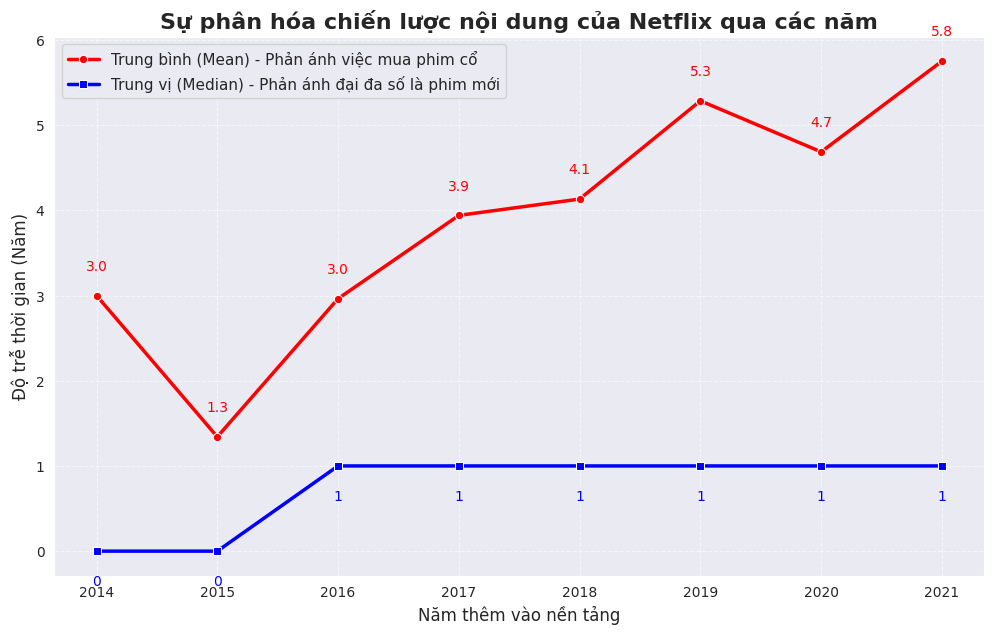

In [6]:
# 1. Tính độ trễ phát hành
df_delay = df.copy()
df_delay['delay_years'] = df_delay['added_year'] - df_delay['release_year']

# 2. Do chỉ có 14 hàng mà delay_years < 0, nên drop luôn 14 hàng đó
df_delay = df_delay[df_delay['delay_years'] >= 0]

# 3. Vẽ biểu đồ
# Bước 1: Gom nhóm và tính CẢ HAI chỉ số (mean và median) cùng lúc
df_trend = df_delay[df_delay['added_year'] >= 2014].groupby('added_year').agg(
    mean_delay=('delay_years', 'mean'),
    median_delay=('delay_years', 'median')
).reset_index()

# Bước 2: Thiết lập kích thước biểu đồ
plt.figure(figsize=(12, 7))

# Bước 3: Vẽ đường Trung bình (Mean) - Màu đỏ
sns.lineplot(data=df_trend, x='added_year', y='mean_delay', 
             marker='o', color='red', linewidth=2.5, 
             label='Trung bình (Mean) - Phản ánh việc mua phim cổ')

# Bước 4: Vẽ đường Trung vị (Median) - Màu xanh
sns.lineplot(data=df_trend, x='added_year', y='median_delay', 
             marker='s', color='blue', linewidth=2.5, 
             label='Trung vị (Median) - Phản ánh đại đa số là phim mới')

# Bước 5: Trang trí biểu đồ để báo cáo
plt.title('Sự phân hóa chiến lược nội dung của Netflix qua các năm', fontsize=16, fontweight='bold')
plt.xlabel('Năm thêm vào nền tảng', fontsize=12)
plt.ylabel('Độ trễ thời gian (Năm)', fontsize=12)

# Hiển thị tất cả các năm trên trục X cho dễ nhìn
plt.xticks(df_trend['added_year']) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')

# Tùy chọn nâng cao: Gắn trực tiếp các con số lên biểu đồ
for i, row in df_trend.iterrows():
    # Gắn số cho Mean (Lệch lên trên một chút)
    plt.text(row['added_year'], row['mean_delay'] + 0.3, f"{row['mean_delay']:.1f}", color='red', ha='center')
    # Gắn số cho Median (Lệch xuống dưới một chút)
    plt.text(row['added_year'], row['median_delay'] - 0.4, f"{row['median_delay']:.0f}", color='blue', ha='center')

# Hiển thị kết quả
plt.show()


Nhận xét biến delay_years:
- Chiến lược cốt lõi (Nhìn vào Trung vị): Luôn duy trì ở mức 0 - 1 năm. Điều này khẳng định hơn 50% nội dung Netflix tung ra luôn là phim mới, bám sát chiến lược tự sản xuất phim độc quyền (Netflix Originals).

- Dấu ấn COVID-19 (Nhìn vào Trung bình): Đột ngột vọt lên đỉnh điểm ~6 năm vào giai đoạn 2020-2021.

- Nguyên nhân: Đại dịch khiến các phim trường đóng băng. Để giữ chân khán giả ở nhà, Netflix buộc phải "chữa cháy" bằng cách mua sỉ hàng ngàn bộ phim điện ảnh kinh điển, khiến độ trễ trung bình bị kéo vọt lên.

Dữ liệu cho thấy Netflix cực kỳ linh hoạt — kiên định đầu tư nội dung mới trong dài hạn, nhưng sẵn sàng gom "hàng cổ" để sinh tồn khi có khủng hoảng.

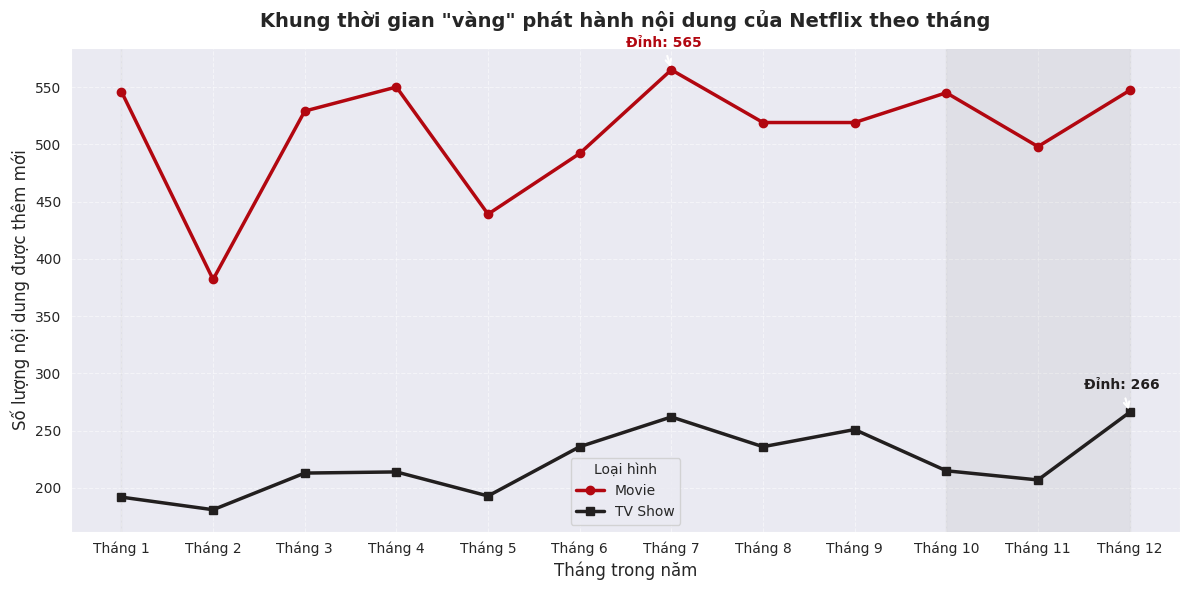

In [7]:
# 1. Trích xuất thông tin tháng từ cột date_added
# Do df đã được xử lý chuẩn hóa ở Cell [4], ta tạo một cột 'month_added'
df_season = df.copy()
df_season['month_added'] = df_season['date_added'].dt.month

# Loại bỏ các dòng không có dữ liệu thời gian nếu có
df_season = df_season.dropna(subset=['month_added'])
df_season['month_added'] = df_season['month_added'].astype(int)

# 2. Gom nhóm theo tháng và loại hình (Movie / TV Show) để đếm số lượng
monthly_counts = df_season.groupby(['month_added', 'type']).size().unstack(fill_value=0)

# Định nghĩa tên các tháng để hiển thị trên trục X cho trực quan
month_names = ['Tháng 1', 'Tháng 2', 'Tháng 3', 'Tháng 4', 'Tháng 5', 'Tháng 6', 
               'Tháng 7', 'Tháng 8', 'Tháng 9', 'Tháng 10', 'Tháng 11', 'Tháng 12']

# 3. Trực quan hóa dữ liệu bằng biểu đồ đường (Line Plot) để thấy rõ xu hướng hình sin
plt.figure(figsize=(12, 6))

# Vẽ đường cho Movie
plt.plot(monthly_counts.index, monthly_counts['Movie'], marker='o', color='#b20710', 
         linewidth=2.5, label='Movie')

# Vẽ đường cho TV Show
plt.plot(monthly_counts.index, monthly_counts['TV Show'], marker='s', color='#221f1f', 
         linewidth=2.5, label='TV Show')

# Cấu hình biểu đồ
plt.title('Khung thời gian "vàng" phát hành nội dung của Netflix theo tháng', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tháng trong năm', fontsize=12)
plt.ylabel('Số lượng nội dung được thêm mới', fontsize=12)
plt.xticks(monthly_counts.index, month_names, fontsize=10)
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.legend(title='Loại hình', fontsize=10)

# Đánh dấu các điểm cao trào (Tháng 10 - Tháng 1) bằng cách tô nền mờ (vùng mùa vụ cao điểm)
plt.axvspan(10, 12, color='gray', alpha=0.1)
plt.axvspan(1, 1, color='gray', alpha=0.1)

# Thêm ghi chú lên biểu đồ tại các điểm đỉnh
for col, color in [('Movie', '#b20710'), ('TV Show', '#221f1f')]:
    # Điểm cao nhất thường rơi vào tháng 12 hoặc tháng 1
    max_month = monthly_counts[col].idxmax()
    max_val = monthly_counts[col].max()
    plt.annotate(f'Đỉnh: {max_val}', 
                 xy=(max_month, max_val), 
                 xytext=(max_month - 0.5, max_val + 20),
                 arrowprops=dict(facecolor=color, arrowstyle="->", lw=1.5),
                 fontweight='bold', color=color)

plt.tight_layout()
plt.show()

Bằng cách trích xuất dữ liệu Tháng từ cột `date_added`, biểu đồ đường thể hiện một xu hướng chu kỳ rất rõ ràng của Netflix trong chiến lược phân phối nội dung:

* **Chu kỳ hình sin / Điểm rơi cuối năm:** Số lượng phim được thêm mới (đặc biệt là Movie) bắt đầu tăng mạnh từ giai đoạn Tháng 10, bùng nổ mạnh mẽ nhất vào **Tháng 11, Tháng 12** và duy trì ở mức cao vào **Tháng 1** năm sau. 
* **Lý do chiến lược:** Đây là giai đoạn trùng khớp với chuỗi kỳ nghỉ lớn trên toàn cầu (Halloween, Thanksgiving, Giáng Sinh, Tết Dương Lịch). Thời tiết mùa đông lạnh tại các thị trường trọng điểm phương Tây kết hợp với các kỳ nghỉ dài ngày thúc đẩy hành vi "binge-watching" (cày phim liên tục) tại nhà, biến đây thành thời điểm hoàn hảo nhất để kích cầu tiêu dùng và giữ chân các thuê bao gia hạn gói tháng.

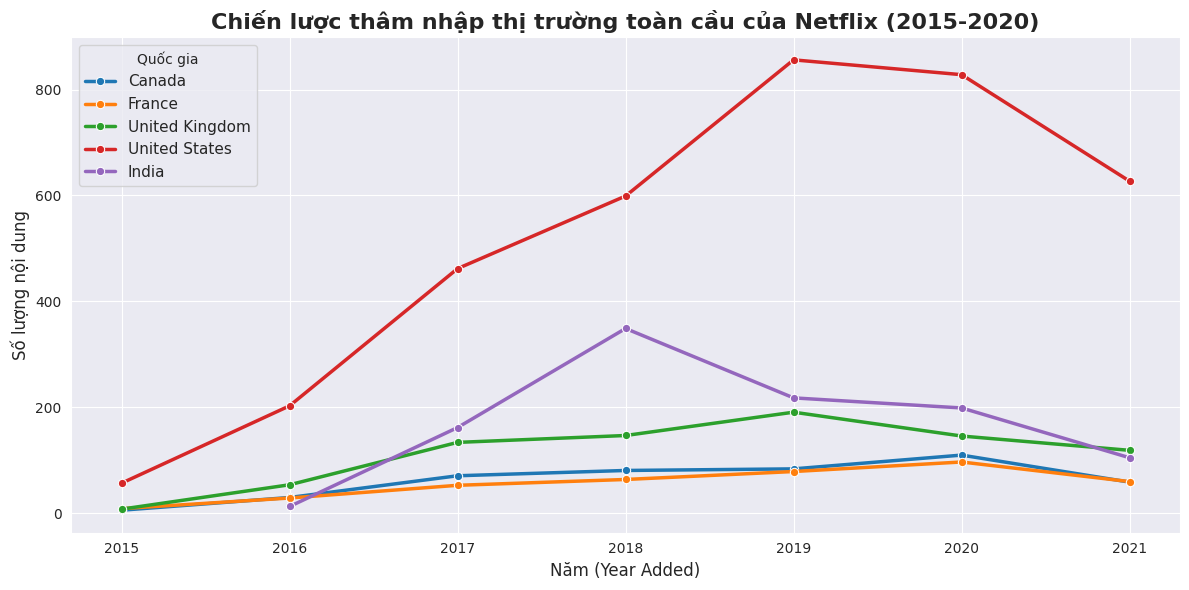

In [8]:
# 1. Lọc bỏ các dòng chưa xác định được quốc gia (Unknown)
df_country = df[df['country'] != 'Unknown'].copy()

# 2. Tách chuỗi các quốc gia và biến mỗi quốc gia thành một dòng riêng biệt
df_country['country'] = df_country['country'].str.split(', ')
df_country = df_country.explode('country')

# 3. Lấy Top 5 quốc gia sản xuất nhiều nội dung nhất trên nền tảng
top_5_countries = df_country['country'].value_counts().head(5).index
df_top = df_country[df_country['country'].isin(top_5_countries)]

# 4. Nhóm dữ liệu theo Năm thêm vào (added_year) và Quốc gia
trend_country = df_top[df_top['added_year'] >= 2015].groupby(['added_year', 'country']).size().reset_index(name='count')
trend_country = trend_country[trend_country['added_year'] <= 2021] # Bỏ qua 2021 vì dữ liệu chưa trọn vẹn

# 5. Cài đặt trực quan hóa
plt.figure(figsize=(12, 6))
sns.set_style("darkgrid")

# Vẽ biểu đồ đường
sns.lineplot(data=trend_country, x='added_year', y='count', hue='country', 
             marker='o', linewidth=2.5, palette='tab10')

# Trang trí biểu đồ
plt.title('Chiến lược thâm nhập thị trường toàn cầu của Netflix (2015-2020)', fontsize=16, fontweight='bold')
plt.xlabel('Năm (Year Added)', fontsize=12)
plt.ylabel('Số lượng nội dung', fontsize=12)
plt.legend(title='Quốc gia', fontsize=11)
plt.tight_layout()

plt.show()

Sự thống trị của "Sân nhà" Mỹ: Đường biểu diễn của United States chắc chắn sẽ nằm cao nhất. Dữ liệu tổng quan cho thấy Mỹ chiếm tới 32% tổng số nội dung trên nền tảng. Đây là cái nôi của Hollywood và là nơi giữ chân tệp khách hàng phương Tây lõi.  Mỏ vàng tỷ dân - Ấn Độ: Bạn sẽ thấy đường biểu diễn của India (chiếm 11% kho nội dung ) có độ dốc vươn lên cực kỳ mạnh mẽ, bám đuổi vị trí số 2. Việc rót vốn mạnh vào Bollywood và các studio địa phương ở Ấn Độ là bài toán Thu hút (Acquisition) kinh điển. Chúng ta không thể mang phim Mỹ đi thuyết phục người dân vùng nông thôn Ấn Độ quẹt thẻ thanh toán được; chúng ta phải cho họ xem văn hóa của chính họ.  Cứu cánh trong Đại dịch: Khi chuỗi cung ứng phim tại Bắc Mỹ đứt gãy vào đầu năm 2020, hệ thống đã bù đắp bằng cách đẩy mạnh mua bản quyền các bộ phim đã hoàn thành ở thị trường quốc tế (như Anh, Pháp, Tây Ban Nha hay Hàn Quốc) để đảm bảo khán giả không bao giờ cảm thấy "hết phim để xem".

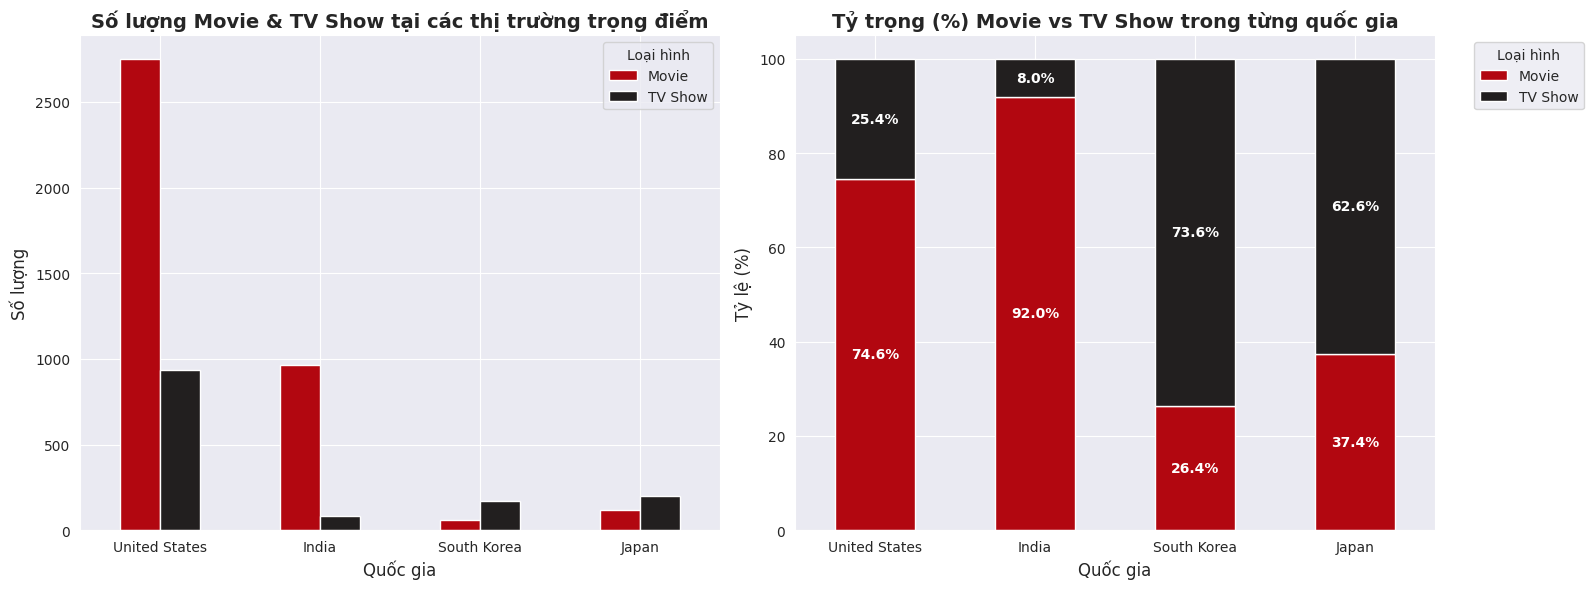

In [9]:
# 1. Sử dụng luôn dataframe df đã được làm sạch từ Cell [4]
# Tiến hành tách các quốc gia bị trùng (được phân tách bằng dấu phẩy)
df_cleaned = df[df['country'] != 'Unknown'].copy()
df_cleaned['country'] = df_cleaned['country'].str.split(', ')
df_exploded = df_cleaned.explode('country')

# 2. Chọn ra các thị trường trọng điểm để làm rõ Insight 4
target_countries = ['United States', 'India', 'South Korea', 'Japan']
df_target = df_exploded[df_exploded['country'].isin(target_countries)]

# 3. Gom nhóm và đếm số lượng Movie / TV Show theo từng quốc gia
country_type_counts = df_target.groupby(['country', 'type']).size().unstack(fill_value=0)
country_type_counts = country_type_counts.reindex(target_countries)

# Tính thêm tỷ lệ % phân bổ nội dung
country_type_percent = country_type_counts.div(country_type_counts.sum(axis=1), axis=0) * 100

# 4. Trực quan hóa dữ liệu
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Số lượng tuyệt đối
country_type_counts.plot(kind='bar', color=['#b20710', '#221f1f'], ax=ax1)
ax1.set_title('Số lượng Movie & TV Show tại các thị trường trọng điểm', fontsize=14, fontweight='bold')
ax1.set_xlabel('Quốc gia', fontsize=12)
ax1.set_ylabel('Số lượng', fontsize=12)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.legend(title='Loại hình')

# Biểu đồ 2: Tỷ lệ phần trăm phân bổ
country_type_percent.plot(kind='bar', stacked=True, color=['#b20710', '#221f1f'], ax=ax2)
ax2.set_title('Tỷ trọng (%) Movie vs TV Show trong từng quốc gia', fontsize=14, fontweight='bold')
ax2.set_xlabel('Quốc gia', fontsize=12)
ax2.set_ylabel('Tỷ lệ (%)', fontsize=12)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(title='Loại hình', bbox_to_anchor=(1.05, 1), loc='upper left')

# Thêm text % vào biểu đồ cột chồng
for p in ax2.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax2.annotate(f'{height:.1f}%', (x + width/2, y + height/2), ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

Khi bóc tách sâu dữ liệu của cột `country` (sau khi đã xử lý các bộ phim hợp tác sản xuất bằng hàm `explode`), chúng ta sẽ thấy một sự phân công nhiệm vụ chiến lược cực kỳ rõ rệt giữa các thị trường trọng điểm của Netflix tại châu Á:

* **Kinh đô Movie - Ấn Độ:** Hơn 90% số lượng nội dung của Ấn Độ trên nền tảng là phim lẻ (Movie). Đây là nguồn cung cấp phim dài tập đồ sộ, phục vụ tệp khán giả trung thành và tối ưu hóa chi phí bản quyền so với siêu sao Hollywood.
* **Thủ phủ TV Show - Hàn Quốc & Nhật Bản:** Ngược lại hoàn toàn với Ấn Độ, Hàn Quốc và Nhật Bản có cơ cấu TV Show (K-Drama và Anime Series) chiếm tỷ trọng áp đảo (trên 60-70%). Đây là "vũ khí chiến lược" giúp Netflix tăng tỷ lệ giữ chân người dùng (User Retention) và duy trì thuê bao tháng tại khu vực Đông Á.

/tmp/ipykernel_16/4209178794.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tv_ma_countries.index, y=top_tv_ma_countries.values,


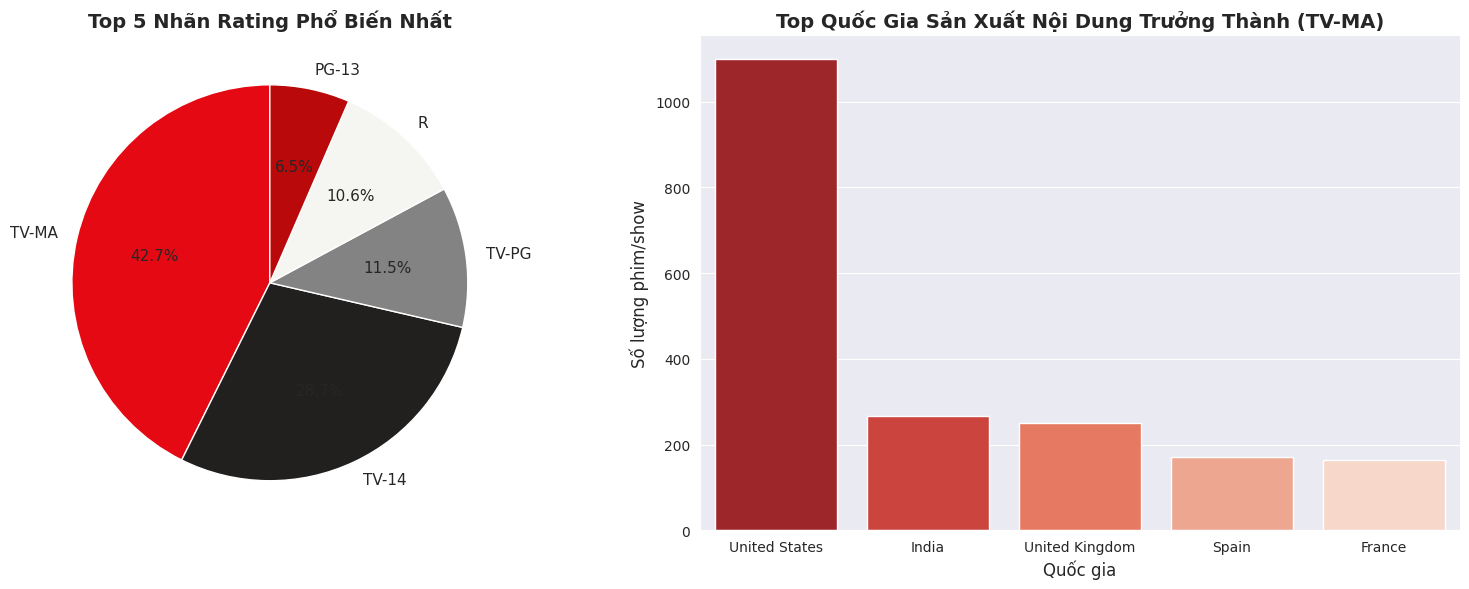

In [10]:
# 1. Làm sạch dữ liệu rating (Lọc bỏ các dòng bị khuyết rating)
df_rating = df.dropna(subset=['rating'])

# Tính toán số lượng và tỷ lệ của Top 5 nhãn rating phổ biến nhất
rating_counts = df_rating['rating'].value_counts().head(5)

# 2. Phân tích sâu (Drill-down) vào nhãn TV-MA
# Lọc ra các nội dung TV-MA
tv_ma_df = df_rating[df_rating['rating'] == 'TV-MA'].copy()

# Tách chuỗi quốc gia và tìm Top 5 quốc gia sản xuất TV-MA nhiều nhất
tv_ma_df['country'] = tv_ma_df['country'].str.split(', ')
tv_ma_df = tv_ma_df.explode('country')
tv_ma_df = tv_ma_df[tv_ma_df['country'] != 'Unknown'] # Bỏ các quốc gia không xác định
top_tv_ma_countries = tv_ma_df['country'].value_counts().head(5)

# 3. Cài đặt trực quan (Canvas 1 hàng, 2 cột)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.set_style("darkgrid")

# Biểu đồ Tròn (Pie Chart) - Tổng quan Rating
colors = ['#E50914', '#221f1f', '#838383', '#f5f5f1', '#b9090b']
ax1.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=colors, textprops={'fontsize': 11})
ax1.set_title('Top 5 Nhãn Rating Phổ Biến Nhất', fontsize=14, fontweight='bold')

# Biểu đồ Cột (Bar Chart) - Top Quốc gia sản xuất TV-MA
sns.barplot(x=top_tv_ma_countries.index, y=top_tv_ma_countries.values, 
            ax=ax2, palette='Reds_r')
ax2.set_title('Top Quốc Gia Sản Xuất Nội Dung Trưởng Thành (TV-MA)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Quốc gia', fontsize=12)
ax2.set_ylabel('Số lượng phim/show', fontsize=12)

plt.tight_layout()
plt.show()

Sức mạnh của nội dung Ngách: Biểu đồ tròn sẽ xác nhận vị trí độc tôn của TV-MA (như bạo lực, ngôn ngữ mạnh, nội dung người lớn). Đây là những thể loại mà truyền hình truyền thống thường e dè hoặc bị kiểm duyệt gắt gao. Bằng cách thoải mái phát sóng các nội dung này, tụi mình tạo ra một "mảnh đất hứa" cho những khán giả thích cảm giác mạnh hoặc những câu chuyện chân thực, gai góc.


Ai đang "cầm trịch" TV-MA? Biểu đồ cột sẽ chỉ ra rằng, ngoài Mỹ, các quốc gia như Tây Ban Nha (với những siêu phẩm như Money Heist - Phi vụ triệu đô) hay Hàn Quốc (với Squid Game - Trò chơi con mực) chính là những mỏ vàng sản xuất nội dung TV-MA xuất sắc nhất.

/tmp/ipykernel_16/1642844937.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, ax=ax1, palette='Blues_r')
/tmp/ipykernel_16/1642844937.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_casts.values, y=top_casts.index, ax=ax2, palette='Greens_r')


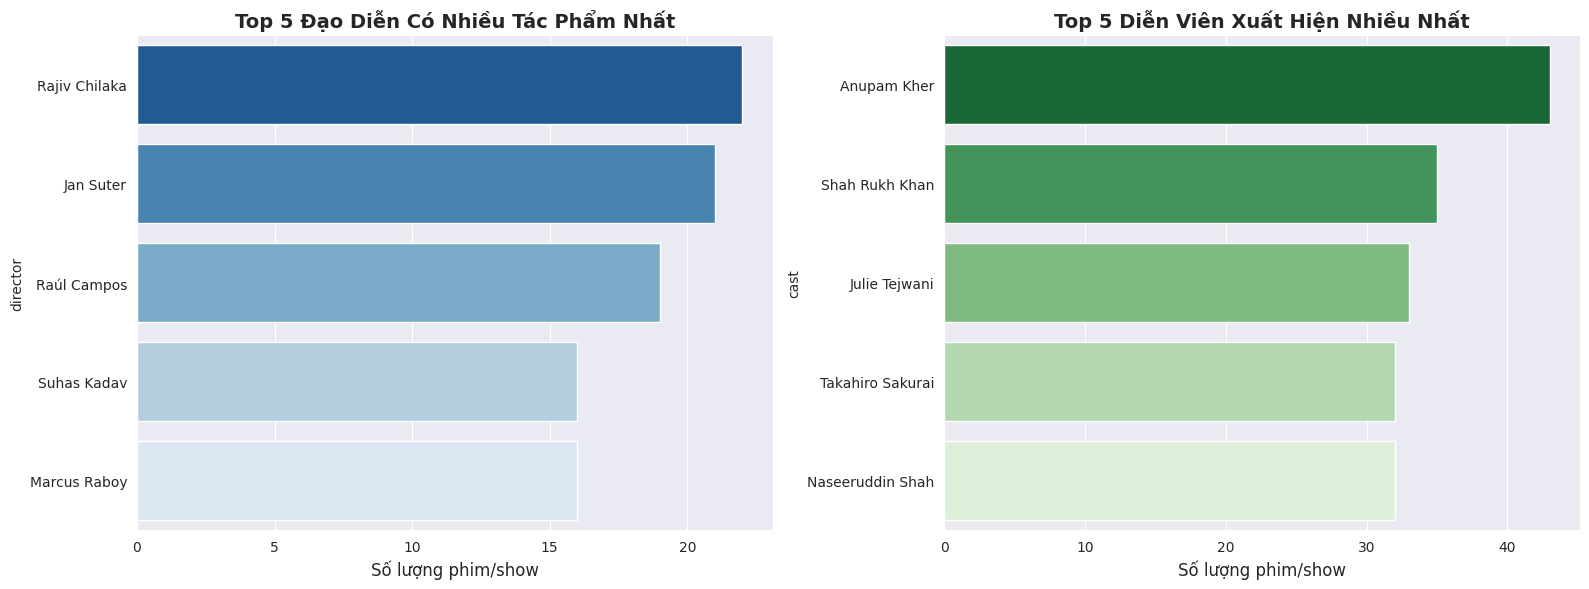

In [11]:
# 1. Chuẩn bị dữ liệu Đạo diễn (Director)
# Lọc bỏ các dòng Unknown và tách chuỗi
df_dir = df[df['director'] != 'Unknown'].copy()
df_dir['director'] = df_dir['director'].str.split(', ')
df_dir = df_dir.explode('director')

# Lấy Top 5 đạo diễn
top_directors = df_dir['director'].value_counts().head(5)

# 2. Chuẩn bị dữ liệu Diễn viên (Cast)
# Lọc bỏ các dòng Unknown và tách chuỗi
df_cast = df[df['cast'] != 'Unknown'].copy()
df_cast['cast'] = df_cast['cast'].str.split(', ')
df_cast = df_cast.explode('cast')

# Lấy Top 5 diễn viên
top_casts = df_cast['cast'].value_counts().head(5)

# 3. Cài đặt trực quan (Canvas 1 hàng, 2 cột)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.set_style("darkgrid")

# Biểu đồ Top Đạo diễn
sns.barplot(x=top_directors.values, y=top_directors.index, ax=ax1, palette='Blues_r')
ax1.set_title('Top 5 Đạo Diễn Có Nhiều Tác Phẩm Nhất', fontsize=14, fontweight='bold')
ax1.set_xlabel('Số lượng phim/show', fontsize=12)

# Biểu đồ Top Diễn viên
sns.barplot(x=top_casts.values, y=top_casts.index, ax=ax2, palette='Greens_r')
ax2.set_title('Top 5 Diễn Viên Xuất Hiện Nhiều Nhất', fontsize=14, fontweight='bold')
ax2.set_xlabel('Số lượng phim/show', fontsize=12)

plt.tight_layout()
plt.show()

Bất ngờ từ Đạo diễn: Bạn sẽ thấy cái tên Rajiv Chilaka thống trị bảng xếp hạng đạo diễn. Ông là cha đẻ của series hoạt hình Ấn Độ đình đám Chhota Bheem. Việc đầu tư mạnh tay vào một đạo diễn phim hoạt hình Ấn Độ minh chứng rõ nét cho chiến lược: Đánh mạnh vào nội dung trẻ em ở thị trường tỷ dân để giữ chân (Retention) toàn bộ cả gia đình.  Ông hoàng Phim Tài liệu: Ở bảng diễn viên, David Attenborough sẽ là một trong những cái tên nổi bật nhất. Ông là giọng đọc huyền thoại của các loạt phim tài liệu thiên nhiên. Khán giả cực kỳ thích bật phim tài liệu thiên nhiên để thư giãn, và chi phí mua/sản xuất thể loại này lại vô cùng tối ưu.  Sức mạnh của Bollywood: Các diễn viên Ấn Độ như Anupam Kher hay Shah Rukh Khan thường xuyên chiếm lĩnh top đầu. Họ là bảo chứng doanh thu ở mỏ vàng Châu Á. Thay vì chi tiền cho một siêu sao Hollywood đóng phim bom tấn chỉ xem một lần rồi thôi, thuật toán mách bảo tụi mình nên chi tiền mua hàng loạt phim của các diễn viên Bollywood để giữ chân cộng đồng khán giả trung thành này.

## 🎯 KẾT LUẬN CHIẾN LƯỢC & HƯỚNG PHÁT TRIỂN (CONCLUSION & FUTURE WORK)

### 1. Tổng kết các Insight cốt lõi từ dữ liệu:
Qua quá trình khai phá dữ liệu (EDA) trên bộ dữ liệu Netflix, chúng ta đã bóc tách được các đặc trưng vận hành cốt lõi của nền tảng:
* **Sự áp đảo của Movie:** Phim lẻ (Movie) vẫn là loại hình nội dung chiếm tỷ trọng lớn nhất trên nền tảng, cho thấy chiến lược tập trung kho phim đa dạng để đáp ứng nhu cầu giải trí nhanh của đại đa số người dùng.
* **Sức hút từ các thị trường lớn:** Sự phân bổ dữ liệu cho thấy vai trò áp đảo của các quốc gia lớn (như Mỹ, Ấn Độ) trong việc định hình kho nội dung toàn cầu của Netflix.
* **Chiến lược giữ chân bằng ngôi sao địa phương:** Việc các diễn viên Bollywood (Ấn Độ) như Anupam Kher hay Shah Rukh Khan xuất hiện liên tục trong top đầu là minh chứng cho thuật toán tối ưu hóa nội dung theo khu vực, giúp giữ chân cộng đồng khán giả trung thành tại "mỏ vàng" Châu Á.

### 2. Đề xuất hướng phát triển bài toán (Future Work):
Để nâng cấp bài phân tích này lên một sản phẩm Data Science hoàn chỉnh, chúng ta có thể mở rộng theo các hướng sau:
1. **Xây dựng Hệ thống Gợi ý (Recommendation System):** Sử dụng các thuật toán như *Collaborative Filtering* dựa trên các đặc trưng như `cast`, `director`, `listed_in` để cá nhân hóa danh mục phim cho từng user.
2. **Dự đoán Nhãn nội dung (Text Classification):** Ứng dụng xử lý ngôn ngữ tự nhiên (NLP) lên cột `description` để tự động phân loại thể loại phim hoặc dự đoán độ tuổi phù hợp (`rating`).